## HW6
### Student : Shkolyar Vladimir


https://github.com/deltadaemon/Decision-Transformer-with-Memory-for-POMDPs/tree/main

## 1. Dataset

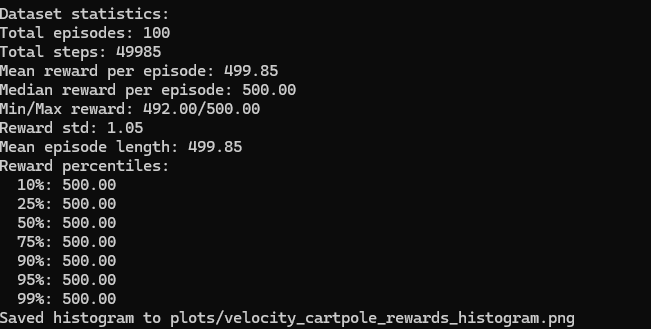

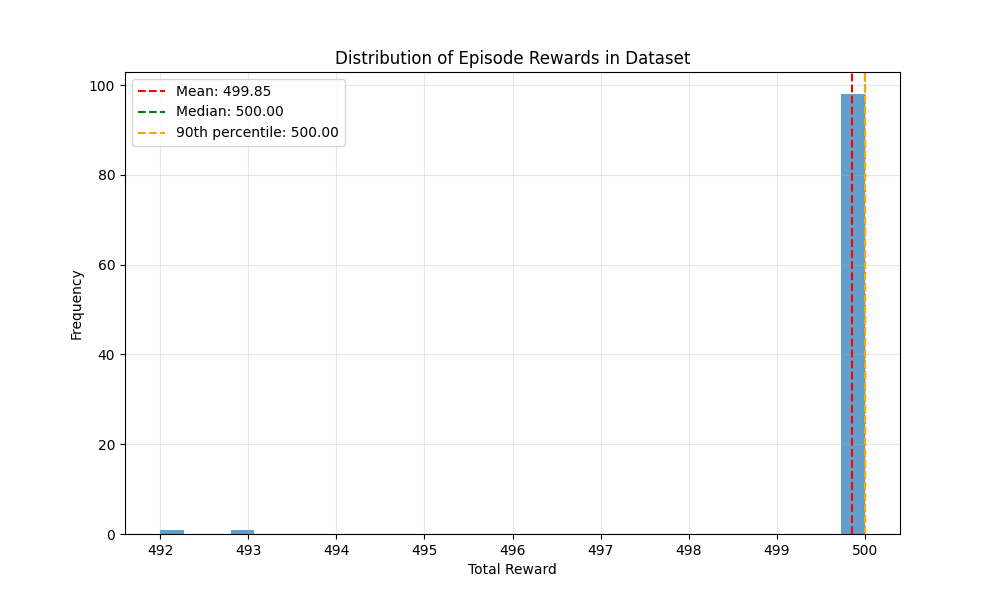

## 2. No mem


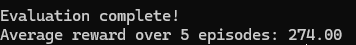

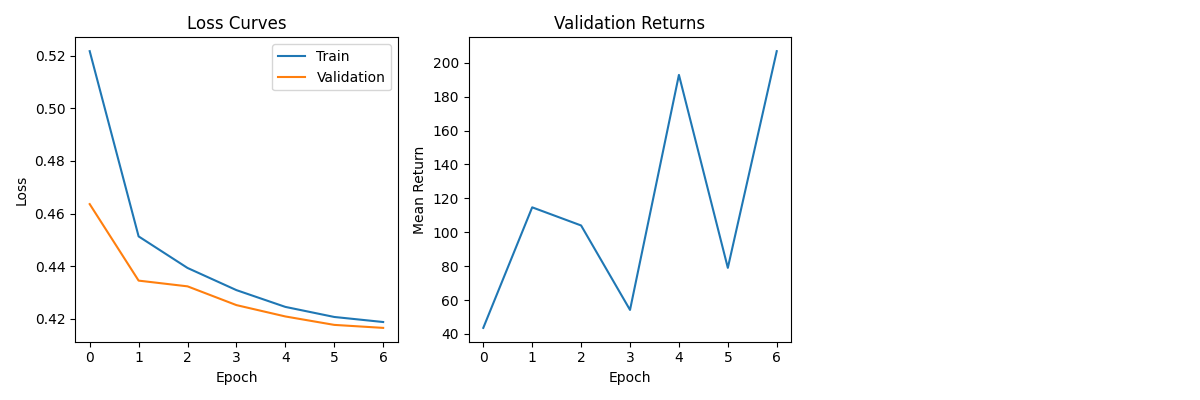

## 3. GRU


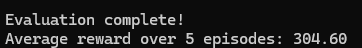

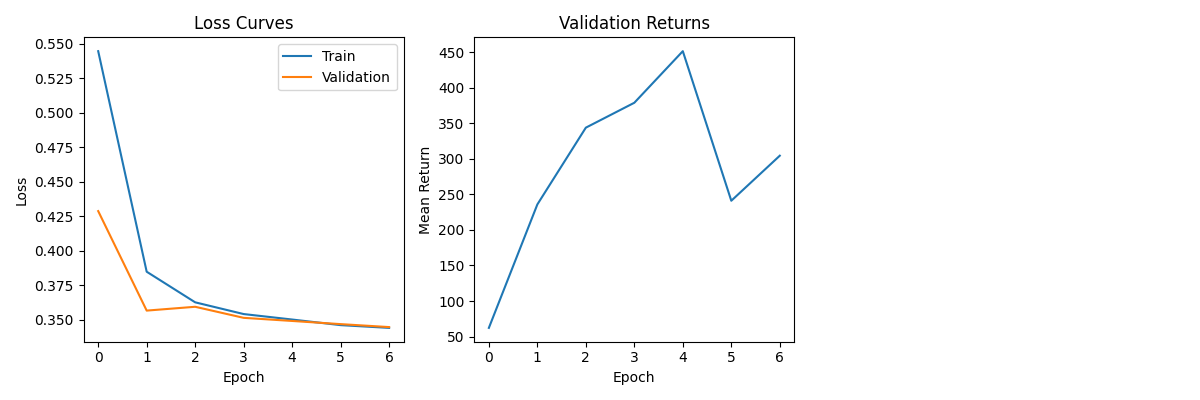

## 4.LSTM

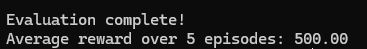

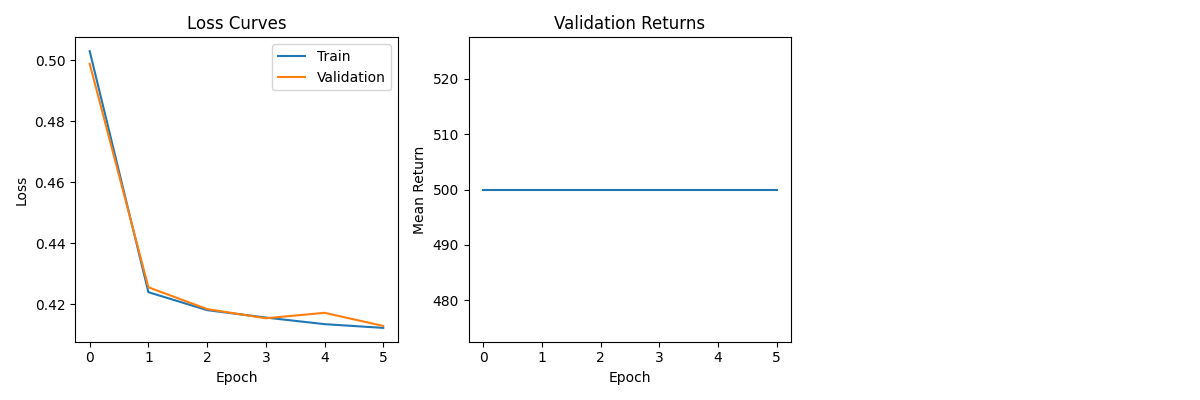

## 5. Сравнение

Общие замечания - датасет формируется нестабильно, пришлось перегенеривать 6 раз, после этого обюучение пошло в целом очень удачно

Оба типа памяти работают хорошо, однако в моих прогонах (5 на каждую из моделей) `lstm` показывает себя стабильно гораздо лучше чуть ли не постоянно выбивая максимальный скор
Расширение контекста прводит к эффективной генерализации истории, что собственно говоря очень даже и заметно

## 6.TCN

```
elif memory_type == 'tcn':
            self.memory = nn.Sequential(
                nn.Conv1d(
                    in_channels=n_embed,
                    out_channels=memory_dim,
                    kernel_size=3,
                    padding=2,
                    dilation=2
                ),
                nn.ReLU(),
                nn.Conv1d(
                    in_channels=memory_dim,
                    out_channels=memory_dim,
                    kernel_size=3,
                    padding=4,
                    dilation=4
                ),
                nn.ReLU()
            )

            self.memory_proj = nn.Linear(memory_dim, n_embed)
```

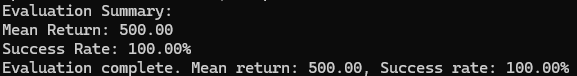

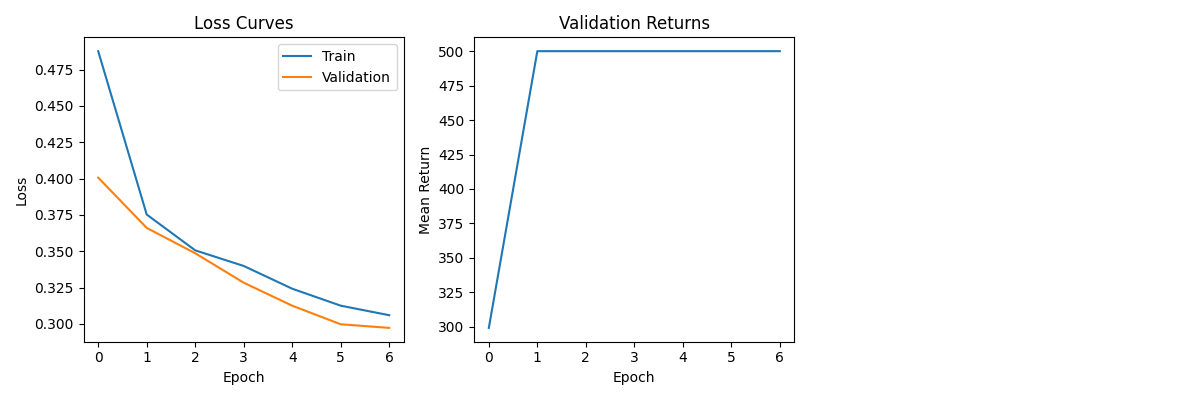

Вместо рекуррентной памяти мы даём модели смотреть на последние K скрытых состояний через 1D свертку
По идее это должно быть стабильней чем LSTM и лучше парралелиться, что собвенно на тестах и было видно (прогонял 10 раз последний не особо удачный)

## Финализация

Рекуррентные архитектуры обучаются значительно проще: они быстрее сходятся и менее чувствительны к выбору гиперпараметров. Напротив, Transformer с модулем памяти потребовал дополнительной настройки параметров, чтобы добиться стабильного обучения модели в рамках заданных ограничений.